<a href="https://colab.research.google.com/github/arushibanerjee20/bioinformatics-basics/blob/main/bioinformatics_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd

# Load RNA-seq count data
file_path = "/content/GSE60424_GEOSubmit_FC1to11_normalized_counts.txt.gz"



df = pd.read_csv(file_path, sep="\t", index_col=0)

# Show basic info
print("Shape of dataset:", df.shape)
print("\nFirst 5 genes:")
print(df.head())


Shape of dataset: (50045, 134)

First 5 genes:
                 lib221  lib222  lib223  lib224  lib225  lib226  lib227  \
genenames                                                                 
ENSG00000000003       1       0       1       1       1       0       0   
ENSG00000000005       0       0       0       0       0       0       0   
ENSG00000000419      23      22      25      28      25      41      18   
ENSG00000000457      11      11      14      17      11      32       9   
ENSG00000000460       3       3       3       3       2       4       5   

                 lib228  lib229  lib230  ...  lib346  lib347  lib348  lib349  \
genenames                                ...                                   
ENSG00000000003       0       2       1  ...       1       0       1       0   
ENSG00000000005       0       0       0  ...       0       0       0       0   
ENSG00000000419      12      14      20  ...      28      19      35      37   
ENSG00000000457      24    

In [23]:
from google.colab import files
files.upload()


In [25]:
!ls /content

'GSE60424_GEOSubmit_FC1to11_normalized_counts.txt (1).gz'
'GSE60424_GEOSubmit_FC1to11_normalized_counts.txt (2).gz'
 GSE60424_GEOSubmit_FC1to11_normalized_counts.txt.gz
 sample_data


In [6]:
list(df.columns)[:20]


['lib221',
 'lib222',
 'lib223',
 'lib224',
 'lib225',
 'lib226',
 'lib227',
 'lib228',
 'lib229',
 'lib230',
 'lib231',
 'lib232',
 'lib233',
 'lib234',
 'lib235',
 'lib236',
 'lib237',
 'lib238',
 'lib239',
 'lib240']

In [7]:
healthy_samples = ['lib221', 'lib226']   # replace with actual healthy libs
ms_samples = ['lib223', 'lib237']        # replace with actual MS libs



In [8]:
len(healthy_samples), len(ms_samples)


(2, 2)

In [9]:
import pandas as pd

metadata = pd.DataFrame({
    'sample': healthy_samples + ms_samples,
    'condition': ['Healthy'] * len(healthy_samples) + ['MS_PostTreatment'] * len(ms_samples)
})

metadata


,sample,condition
0,lib221,Healthy
1,lib226,Healthy
2,lib223,MS_PostTreatment
3,lib237,MS_PostTreatment


In [27]:
df = pd.read_csv(file_path, sep="\t", index_col=0)
df = df[metadata['sample']]
df.head()


,lib221,lib226,lib223,lib237
genenames,,,,
ENSG00000000003,1,0,1,0
ENSG00000000005,0,0,0,0
ENSG00000000419,23,41,25,32
ENSG00000000457,11,32,14,27
ENSG00000000460,3,4,3,3


In [28]:
print(df.columns.tolist())
print(metadata)


['lib221', 'lib226', 'lib223', 'lib237']
   sample         condition
0  lib221           Healthy
1  lib226           Healthy
2  lib223  MS_PostTreatment
3  lib237  MS_PostTreatment


In [29]:
import numpy as np

df_log = np.log2(df + 1)
df_log.head()


,lib221,lib226,lib223,lib237
genenames,,,,
ENSG00000000003,1.000000,0.000000,1.000000,0.000000
ENSG00000000005,0.000000,0.000000,0.000000,0.000000
ENSG00000000419,4.584963,5.392317,4.700440,5.044394
ENSG00000000457,3.584963,5.044394,3.906891,4.807355
ENSG00000000460,2.000000,2.321928,2.000000,2.000000


/tmp/ipython-input-3570814269.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_log.values, labels=df_log.columns)


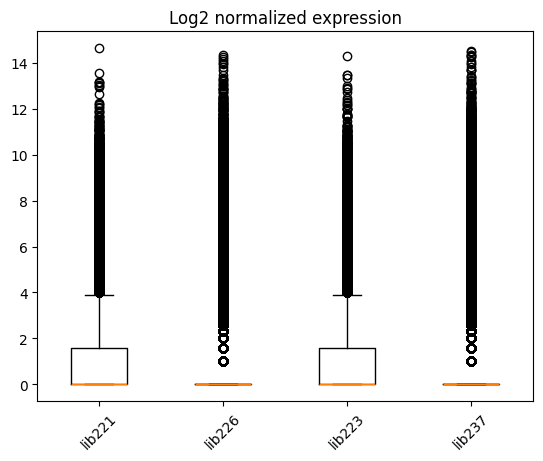

In [30]:
import matplotlib.pyplot as plt

plt.boxplot(df_log.values, labels=df_log.columns)
plt.xticks(rotation=45)
plt.title("Log2 normalized expression")
plt.show()


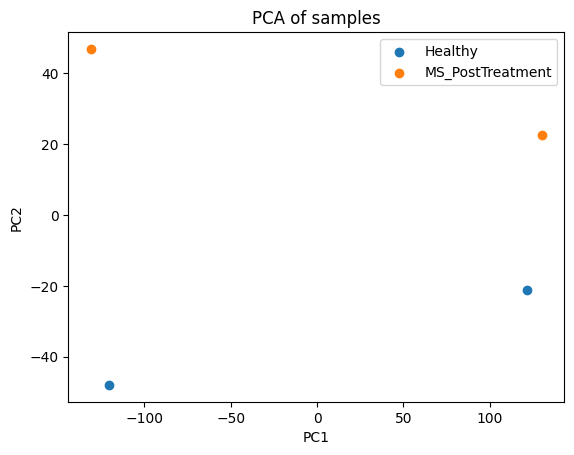

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_log.T)

plt.figure()
for condition in metadata['condition'].unique():
    idx = metadata['condition'] == condition
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=condition)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of samples")
plt.show()
